In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

PREPROC_DIR = Path("../data/preprocessed_targets/train")
DATA_ROOT = Path("../data")

INDEX_PATH = PREPROC_DIR / "index.json"
CONFIG_PATH = PREPROC_DIR / "preprocess_config.json"
CLASS_MAP_PATH = PREPROC_DIR / "class_to_id.json"


with open(INDEX_PATH, "r", encoding="utf-8") as f:
    index = json.load(f)

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = json.load(f)

with open(CLASS_MAP_PATH, "r", encoding="utf-8") as f:
    class_to_id = json.load(f)

id_to_class = {v: k for k, v in class_to_id.items()}

print(f"Number of preprocessed samples: {len(index)}")
print(config)


def load_preprocessed_sample(sample_idx):
    sample_info = index[sample_idx]
    npz_path = Path(sample_info["target_path"])

    data = np.load(npz_path, allow_pickle=True)

    target = data["target"]                      # [S, H, W]
    bg_path = str(data["bg_path"])
    fg_class = str(data["fg_class"])
    class_id = int(data["class_id"])
    num_rows = int(data["num_rows"])

    image_path = DATA_ROOT / bg_path
    image = Image.open(image_path).convert("RGB")

    return {
        "sample_info": sample_info,
        "target": target,
        "bg_path": bg_path,
        "fg_class": fg_class,
        "class_id": class_id,
        "num_rows": num_rows,
        "image": image,
        "image_path": image_path,
    }

sample = load_preprocessed_sample(200)

print("bg_path:", sample["bg_path"])
print("fg_class:", sample["fg_class"])
print("class_id:", sample["class_id"])
print("num_rows:", sample["num_rows"])
print("target shape:", sample["target"].shape)
print("target sum:", sample["target"].sum())

Number of preprocessed samples: 24994
{'label': 1, 'grid_size': 32, 'num_scales': 8, 'sigma_xy': 1.25, 'sigma_s': 0.6, 'score_temperature': 0.3, 'reward_higher_is_better': False, 'scale_bin_edges': [-9.144499599136552, -8.001437149244483, -6.858374699352414, -5.715312249460345, -4.572249799568276, -3.429187349676207, -2.286124899784138, -1.143062449892069, 0.0]}
bg_path: data_large_standard/b/bathroom/00003290.jpg
fg_class: toothbrush
class_id: 44
num_rows: 148
target shape: (8, 32, 32)
target sum: 1.0


In [2]:
def show_image(sample, figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(sample["image"])
    plt.title(f'Image\nclass="{sample["fg_class"]}", class_id={sample["class_id"]}')
    plt.axis("off")
    plt.show()

def show_summed_heatmap(sample, figsize=(6, 6), cmap="hot"):
    target = sample["target"]                   # [S, H, W]
    summed = target.sum(axis=0)                 # [H, W]

    plt.figure(figsize=figsize)
    plt.imshow(summed, cmap=cmap)
    plt.title(f'Summed heatmap over scales\nclass="{sample["fg_class"]}"')
    plt.colorbar()
    plt.axis("off")
    plt.show()

def show_overlay(sample, alpha=0.45, figsize=(7, 7), cmap="jet"):
    image = np.array(sample["image"])
    target = sample["target"]
    summed = target.sum(axis=0)

    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.imshow(
        summed,
        cmap=cmap,
        alpha=alpha,
        extent=(0, image.shape[1], image.shape[0], 0),
        interpolation="bilinear",
    )
    plt.title(f'Overlay: summed heatmap on image\nclass="{sample["fg_class"]}"')
    plt.axis("off")
    plt.show()


def show_scale_slices(sample, cols=4, figsize_per_plot=4, cmap="hot"):
    target = sample["target"]   # [S, H, W]
    num_scales = target.shape[0]
    rows = int(np.ceil(num_scales / cols))

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(cols * figsize_per_plot, rows * figsize_per_plot)
    )
    axes = np.array(axes).reshape(-1)

    vmax = target.max()

    for s in range(num_scales):
        ax = axes[s]
        im = ax.imshow(target[s], cmap=cmap, vmin=0, vmax=vmax)
        ax.set_title(f"Scale bin {s}")
        ax.axis("off")

    for i in range(num_scales, len(axes)):
        axes[i].axis("off")

    fig.suptitle(f'Scale slices for class="{sample["fg_class"]}"', fontsize=16)
    plt.tight_layout()
    plt.show()

def show_scale_overlay(sample, scale_bin, alpha=0.45, figsize=(7, 7), cmap="jet"):
    image = np.array(sample["image"])
    target = sample["target"]

    assert 0 <= scale_bin < target.shape[0], "Invalid scale_bin"

    heat = target[scale_bin]

    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.imshow(
        heat,
        cmap=cmap,
        alpha=alpha,
        extent=(0, image.shape[1], image.shape[0], 0),
        interpolation="bilinear",
    )
    plt.title(f'Overlay for scale bin {scale_bin}\nclass="{sample["fg_class"]}"')
    plt.axis("off")
    plt.show()

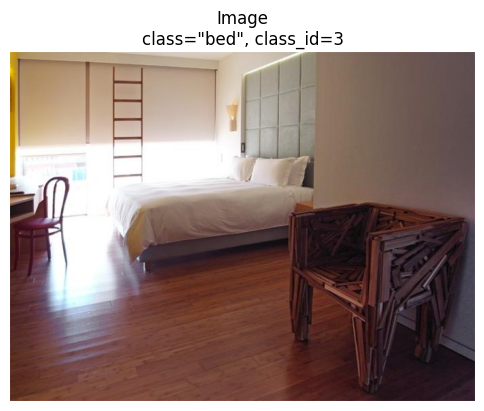

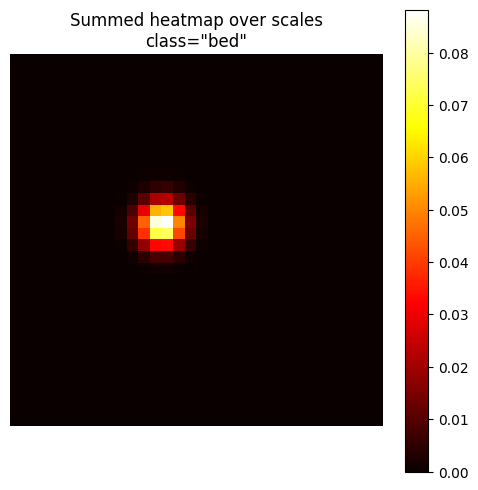

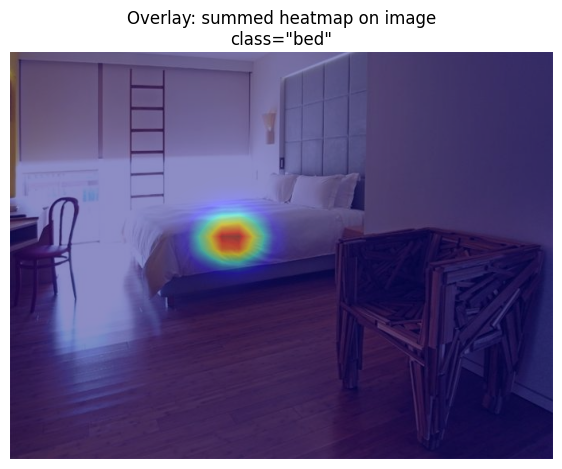

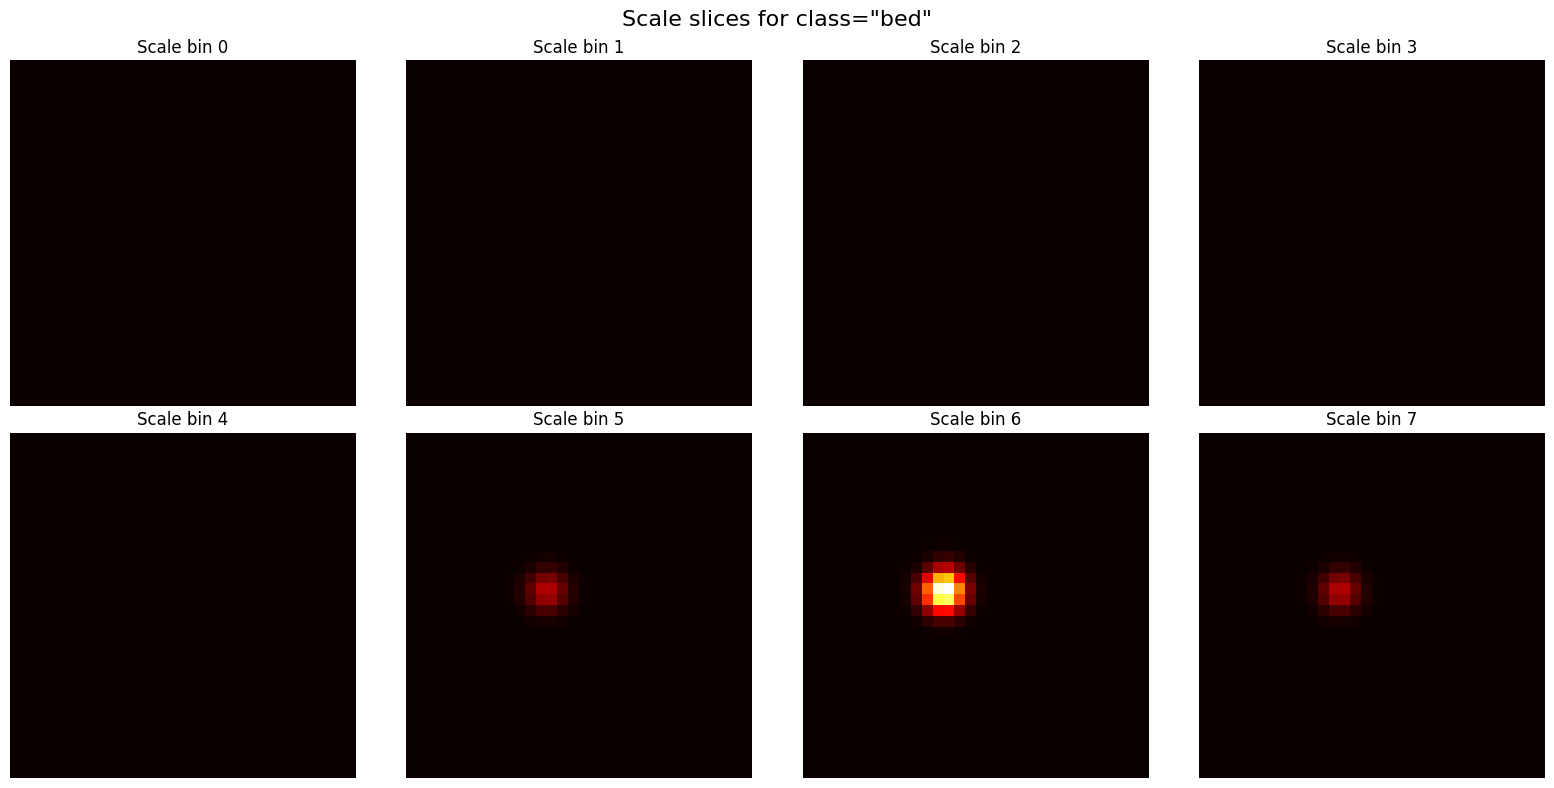

In [6]:
sample = load_preprocessed_sample(21)
show_image(sample)
show_summed_heatmap(sample)
show_overlay(sample)
show_scale_slices(sample)